In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
from tqdm import tqdm

import os

# Variables

In [2]:
# Train Headway (min)
train_headway_list = [10, 20, 30]

# MoD Fleet Size
mod_fleet_size_list = [30, 50, 70, 90, 110, 130, 150]

# MaaS Platform Communication Strategy
maas_communication_strategy_list = ['default', 'TPCS']

# Random Seed
random_seed_list = [3, 6, 9]

# MoD Waiting Time Threshold (s)
mod_waiting_time_threshold_list = [300, 600, 900]
# MoD Detour Time Threshold (%)
mod_detour_time_threshold_list = [30, 60, 90]

# Demand Size
demand_size_list = [i for i in range(100, 1001, 100)]
# Demand Split Ratio (Intra Modal, %)
demand_split_ratio_list = [0, 20, 40, 60, 80]

# Total Simulation Time (s)
total_sim_time = [0, 10800]  # 3 hours
# Warm-up Time (s)
warmup_time = 3600  # 1 hour
# Simulation Time Period (s)
time_period = [warmup_time, total_sim_time[1]+warmup_time]  # 1h + 3h

name_dict = {
    'random_seed': "Random Seed", 
    'fleet_size': "Fleet Size",
    'demand_size': "Demand Size",
    'intra_ratio': "Intra Demand Ratio",
    'op_max_detour_time_factor': "Max Detour Time Factor",
    'op_max_wait_time': "Max Wait Time",
    'train_headway': "Train Headway",
    'average_journey_time': "Average Journey Time",
    'average_intercity_journey_time': "Average Intercity Journey Time",
    'average_intracity_journey_time': "Average Intracity Journey Time",
    'average_journey_time_extended': "Average Journey Time (Extended)",
    'average_intercity_journey_time_extended': "Average Intercity Journey Time (Extended)",
    'average_intracity_journey_time_extended': "Average Intracity Journey Time (Extended)",
    'average_amod_service_rate': "Average AMoD Service Rate",
    'total_amod_cost': "Total AMoD Cost",
    'broker_type': "MaaS Communication Strategy",
    'fleet_utilization_rate': "Fleet Utilization Rate",
}

amod_request_level_analysis_folder = "data/amod-sim-results"

demand_files_folder = "data/demand/11-500/amod"

In [3]:
# All scenario combinations without train headway
all_scenario_combinations_no_train_headway = list(product(
    random_seed_list,
    mod_fleet_size_list,
    demand_size_list,
    demand_split_ratio_list,
    maas_communication_strategy_list,
    mod_detour_time_threshold_list,
    mod_waiting_time_threshold_list,
))

# All Results

In [4]:
# # Merge all AMoD request-level analysis results
# all_results = []
# for scenario in tqdm(all_scenario_combinations_no_train_headway):
#     for train_headway in train_headway_list:
#         random_seed, fleet_size, demand_size, intra_ratio, broker_type, op_max_detour_time_factor,op_max_wait_time = scenario
#         scenario_name = f"amod-{demand_size}-{intra_ratio}-{fleet_size}-{broker_type}-{op_max_detour_time_factor}-{op_max_wait_time}-{train_headway}-{random_seed}-{time_period[0]}-{time_period[1]}"
#         amod_request_level_analysis_results_filepath = os.path.join(amod_request_level_analysis_folder, scenario_name, 'amod_request_level_analysis_results.csv')
#         amod_request_level_analysis_results = pd.read_csv(amod_request_level_analysis_results_filepath)
#         all_results.append(amod_request_level_analysis_results)

# amod_request_level_analysis = pd.concat(all_results, ignore_index=True)
# # Save merged results
# amod_request_level_analysis_filepath = os.path.join(amod_request_level_analysis_folder, "all_amod_request_level_analysis_results.csv")
# amod_request_level_analysis.to_csv(amod_request_level_analysis_filepath, index=False)

In [5]:
# Load request-level analysis data
amod_request_level_analysis_filepath = os.path.join(amod_request_level_analysis_folder, "all_amod_request_level_analysis_results.csv")
amod_request_level_analysis = pd.read_csv(amod_request_level_analysis_filepath)

In [6]:
# Keep only intercity requests
inter_amod_request_level_analysis = amod_request_level_analysis[amod_request_level_analysis['rq_type'] == 'inter'].copy()

# Group by broker type
tpcs_inter_amod_request_level_analysis = inter_amod_request_level_analysis[inter_amod_request_level_analysis['broker_type'] == 'TPCS']
default_inter_amod_request_level_analysis = inter_amod_request_level_analysis[inter_amod_request_level_analysis['broker_type'] == 'default']

# Group by train headway
pt_station_arrival_times_dict = {}
for train_headway in tqdm(train_headway_list):
    train_tpcs = tpcs_inter_amod_request_level_analysis[tpcs_inter_amod_request_level_analysis['headway'] == train_headway]
    train_default = default_inter_amod_request_level_analysis[default_inter_amod_request_level_analysis['headway'] == train_headway]

    left_train_tpcs = train_tpcs[train_tpcs['subnetwork'] == 'left']
    right_train_tpcs = train_tpcs[train_tpcs['subnetwork'] == 'right']
    left_train_default = train_default[train_default['subnetwork'] == 'left']
    right_train_default = train_default[train_default['subnetwork'] == 'right']

    left_tpcs_depart_times = left_train_tpcs['pt_start_time'].values.tolist()
    left_tpcs_arrival_times = right_train_tpcs['lm_start_time'].values.tolist()

    right_tpcs_depart_times = right_train_tpcs['pt_start_time'].values.tolist()
    right_tpcs_arrival_times = left_train_tpcs['lm_start_time'].values.tolist()

    left_default_depart_times = left_train_default['pt_start_time'].values.tolist()
    left_default_arrival_times = right_train_default['lm_start_time'].values.tolist()

    right_default_depart_times = right_train_default['pt_start_time'].values.tolist()
    right_default_arrival_times = left_train_default['lm_start_time'].values.tolist()

    pt_station_arrival_times_dict[train_headway] = {
        'TPCS': [left_tpcs_depart_times, left_tpcs_arrival_times, right_tpcs_depart_times, right_tpcs_arrival_times],
        'Default': [left_default_depart_times, left_default_arrival_times, right_default_depart_times, right_default_arrival_times],
    }

100%|██████████| 3/3 [00:04<00:00,  1.37s/it]


In [16]:
sns.set_theme(style="whitegrid")

def time_str_to_seconds(t_str):
    if pd.isna(t_str):
        return None
    try:
        h, m, s = map(int, t_str.split(':'))
        return h * 3600 + m * 60 + s
    except Exception as e:
        print(f"{t_str}, {e}")
        return None

def load_gtfs_schedule(train_headway, base_path='data/GTFS/train'):
    folder_name = f"train_headway_{train_headway}"
    file_path = os.path.join(base_path, folder_name, 'matched', 'stop_times_fp.txt')
    
    print(f"Reading GTFS file: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"Warning: File does not exist {file_path}")
        return None

    try:
        df = pd.read_csv(file_path)

        df['arrival_seconds'] = df['arrival_time'].apply(time_str_to_seconds)
        df['departure_seconds'] = df['departure_time'].apply(time_str_to_seconds)
        
        schedule = {
            'Left': df[df['stop_id'] == 'MH-L-0'][['arrival_seconds', 'departure_seconds']],
            'Right': df[df['stop_id'] == 'MH-R-0'][['arrival_seconds', 'departure_seconds']]
        }
        return schedule
    except Exception as e:
        print(f"Failed to read GTFS file: {e}")
        return None

def plot_arrival_distributions(arrival_dict, train_headway, gtfs_base_path='data/GTFS/train'):
    """
    Plot distributions in two separate figures:
    1. Departure Times (2x2: TPCS/Default x Left/Right)
    2. Arrival Times (2x2: TPCS/Default x Left/Right)
    """
    # 1. Validate data existence
    if train_headway not in arrival_dict:
        print(f"Key {train_headway} not found in dictionary.")
        return

    data_structure = arrival_dict[train_headway]
    categories = ['TPCS', 'Default']
    
    # 2. Calculate global max time for consistent X-axis across ALL plots
    all_times = []
    for cat in categories:
        if len(data_structure[cat]) != 4:
            print(f"Warning: Data list for {cat} must have length 4.")
            continue
        for sub_list in data_structure[cat]:
            all_times.extend(sub_list)
    
    if not all_times:
        print("No data available for plotting.")
        return

    max_time = max(all_times)
    global_xlim = (0, max_time + 300) 

    # 3. Load GTFS Ground Truth
    gtfs_schedule = load_gtfs_schedule(train_headway, gtfs_base_path)

    # 4. Define configurations for the two figures
    # Data List Structure: [Left_Dep(0), Left_Arr(1), Right_Dep(2), Right_Arr(3)]
    
    figures_config = [
        {
            'fig_type': 'Departure',
            'title': f'Departure Times Distribution (Headway: {train_headway})',
            'line_color': 'red',
            'line_style': ':',
            'data_indices': {'Left': 0, 'Right': 2}, # Index in the data list
            'gtfs_col': 'departure_seconds'
        },
        {
            'fig_type': 'Arrival',
            'title': f'Arrival Times Distribution (Headway: {train_headway})',
            'line_color': 'green',
            'line_style': '--',
            'data_indices': {'Left': 1, 'Right': 3}, # Index in the data list
            'gtfs_col': 'arrival_seconds'
        }
    ]

    directions = ['Left', 'Right']

    # 5. Generate Plots
    for config in figures_config:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
        fig.suptitle(config['title'], fontsize=18)
        
        fig_type = config['fig_type']
        line_color = config['line_color']
        line_style = config['line_style']
        gtfs_col = config['gtfs_col']
        
        for row_idx, category in enumerate(categories):
            for col_idx, direction in enumerate(directions):
                ax = axes[row_idx, col_idx]
                
                # Get specific data list
                list_idx = config['data_indices'][direction]
                time_data = data_structure[category][list_idx]
                
                # --- Plot Histogram ---
                if time_data:
                    sns.histplot(
                        time_data, 
                        ax=ax, 
                        binwidth=60, # 1 minute bins
                        color='skyblue', 
                        edgecolor='black',
                        alpha=0.6
                    )
                
                # # --- Plot GTFS Ground Truth ---
                # if gtfs_schedule and direction in gtfs_schedule:
                #     sched_df = gtfs_schedule[direction]
                #     for _, trip in sched_df.iterrows():
                #         t_val = trip[gtfs_col]
                #         if pd.notna(t_val) and t_val <= global_xlim[1]:
                #             ax.axvline(x=t_val, color=line_color, linestyle=line_style, linewidth=2, alpha=0.9)

                # --- Labels & Titles ---
                station_code = 'MH-L-0' if direction == 'Left' else 'MH-R-0'
                ax.set_title(f"{category} - {direction} Station ({station_code})", fontsize=12, fontweight='bold')
                ax.set_xlim(global_xlim)
                
                if row_idx == 1:
                    ax.set_xlabel("Time (seconds)")
                if col_idx == 0:
                    ax.set_ylabel("Frequency")
                
                # --- Legend (First subplot only) ---
                if row_idx == 0 and col_idx == 0:
                    from matplotlib.lines import Line2D
                    custom_lines = [
                        Line2D([0], [0], color='skyblue', lw=4, alpha=0.6),
                        Line2D([0], [0], color=line_color, linestyle=line_style, lw=2)
                    ]
                    ax.legend(custom_lines, ['Simulated Dist.', f'GTFS {fig_type}'], loc='upper right')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


# Train 10 min

Reading GTFS file: data/GTFS/train\train_headway_10\matched\stop_times_fp.txt


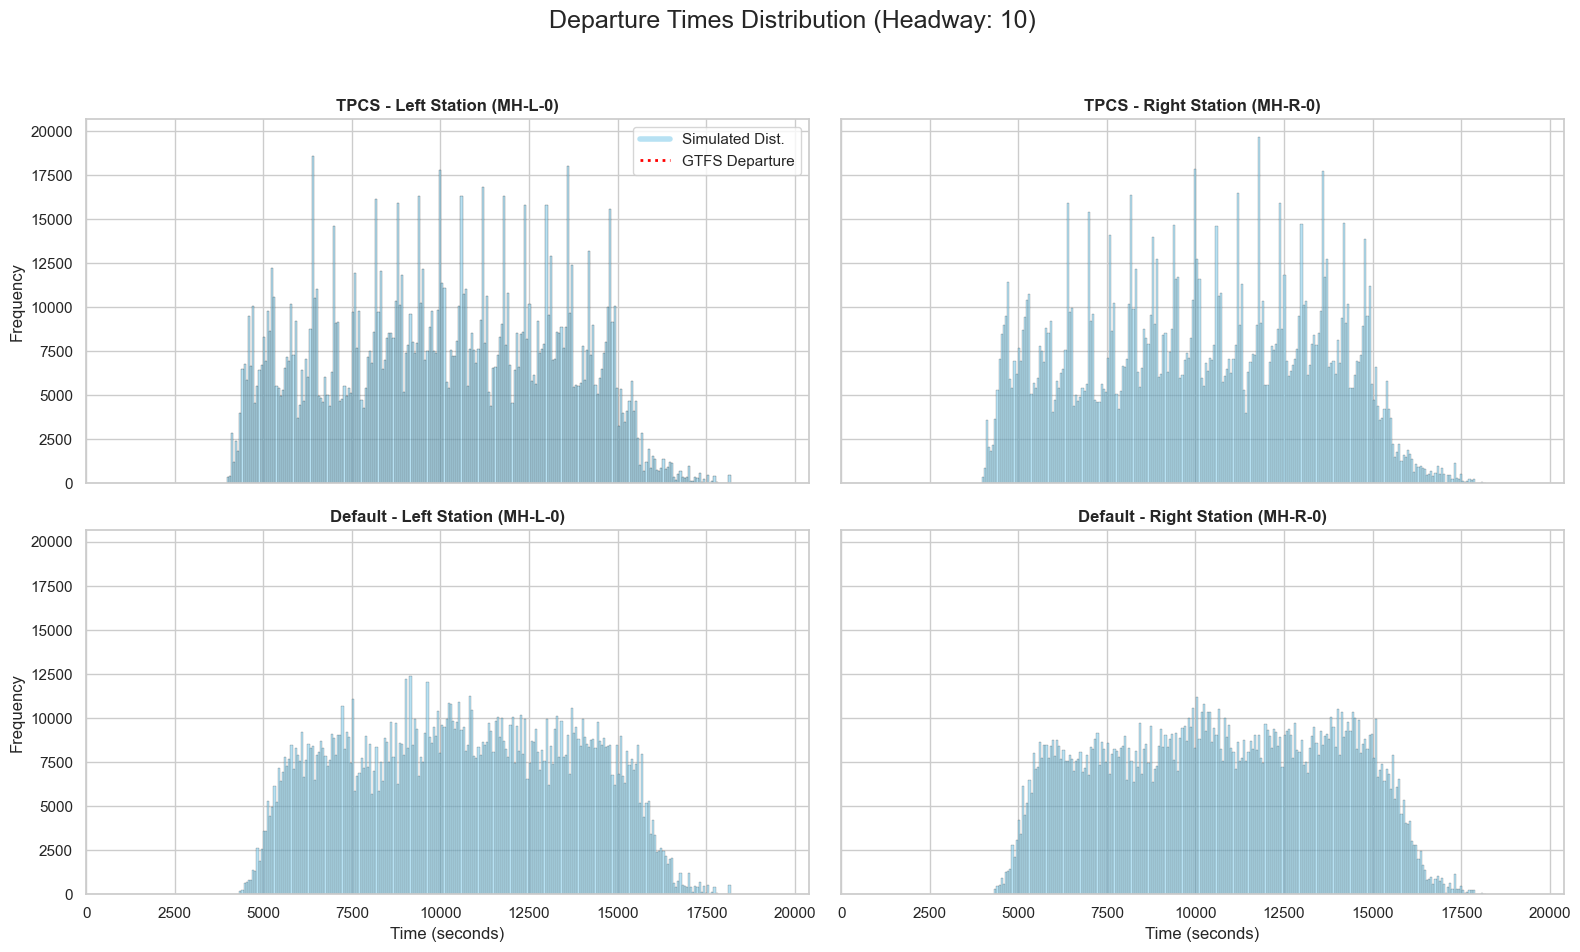

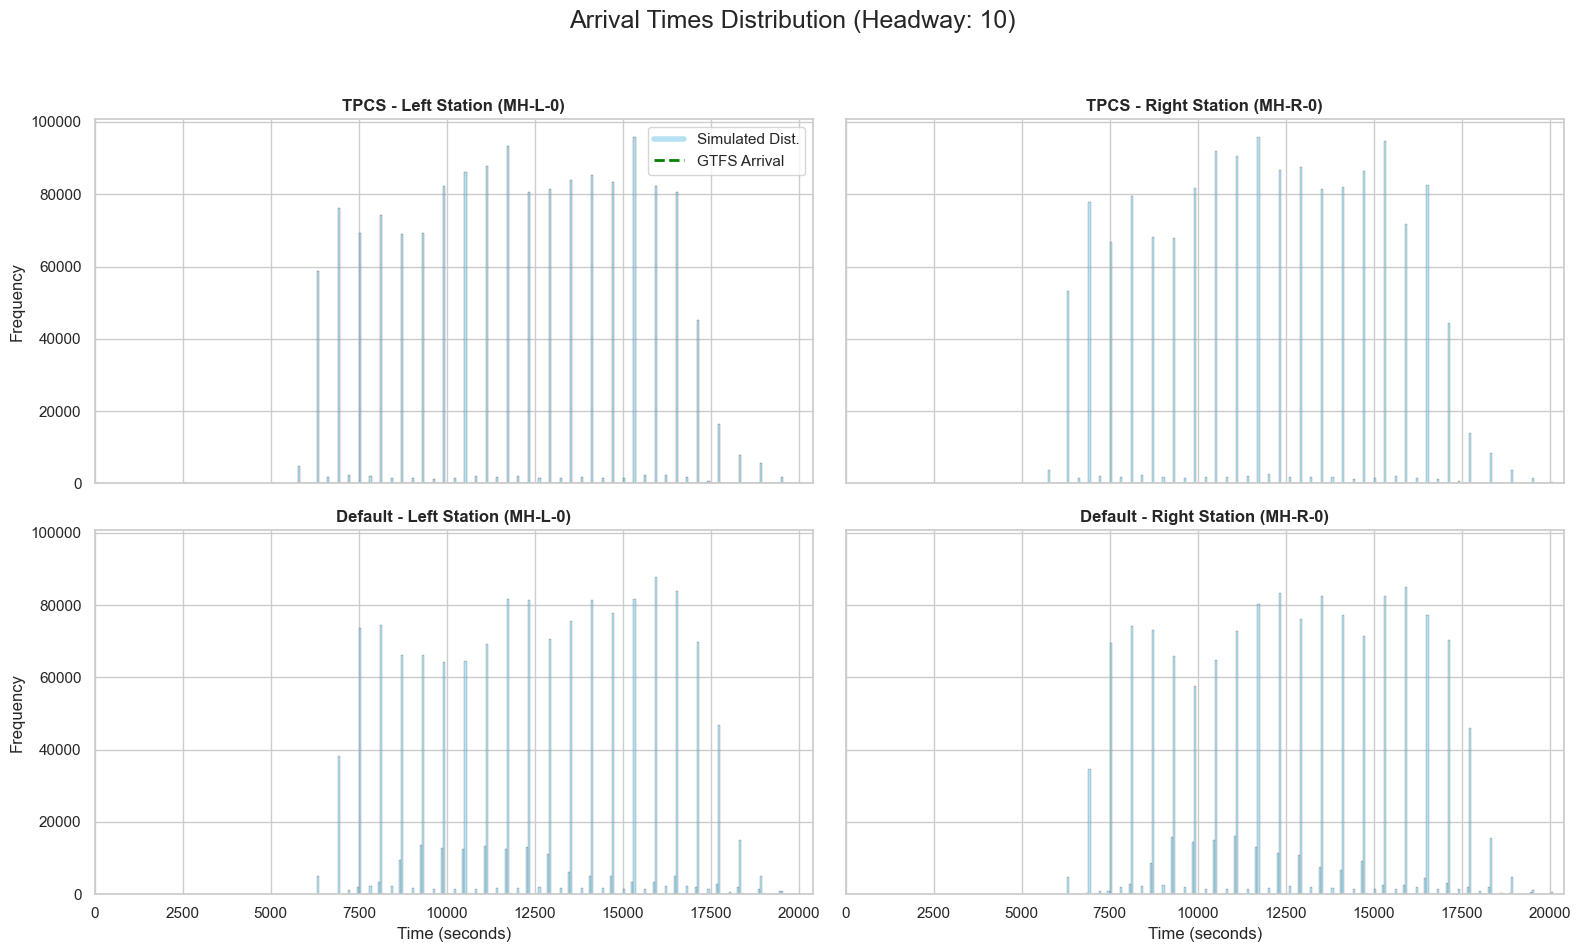

In [10]:
plot_arrival_distributions(arrival_dict=pt_station_arrival_times_dict, train_headway=10, gtfs_base_path='data/GTFS/train')

# Train 20 min

Reading GTFS file: data/GTFS/train\train_headway_20\matched\stop_times_fp.txt


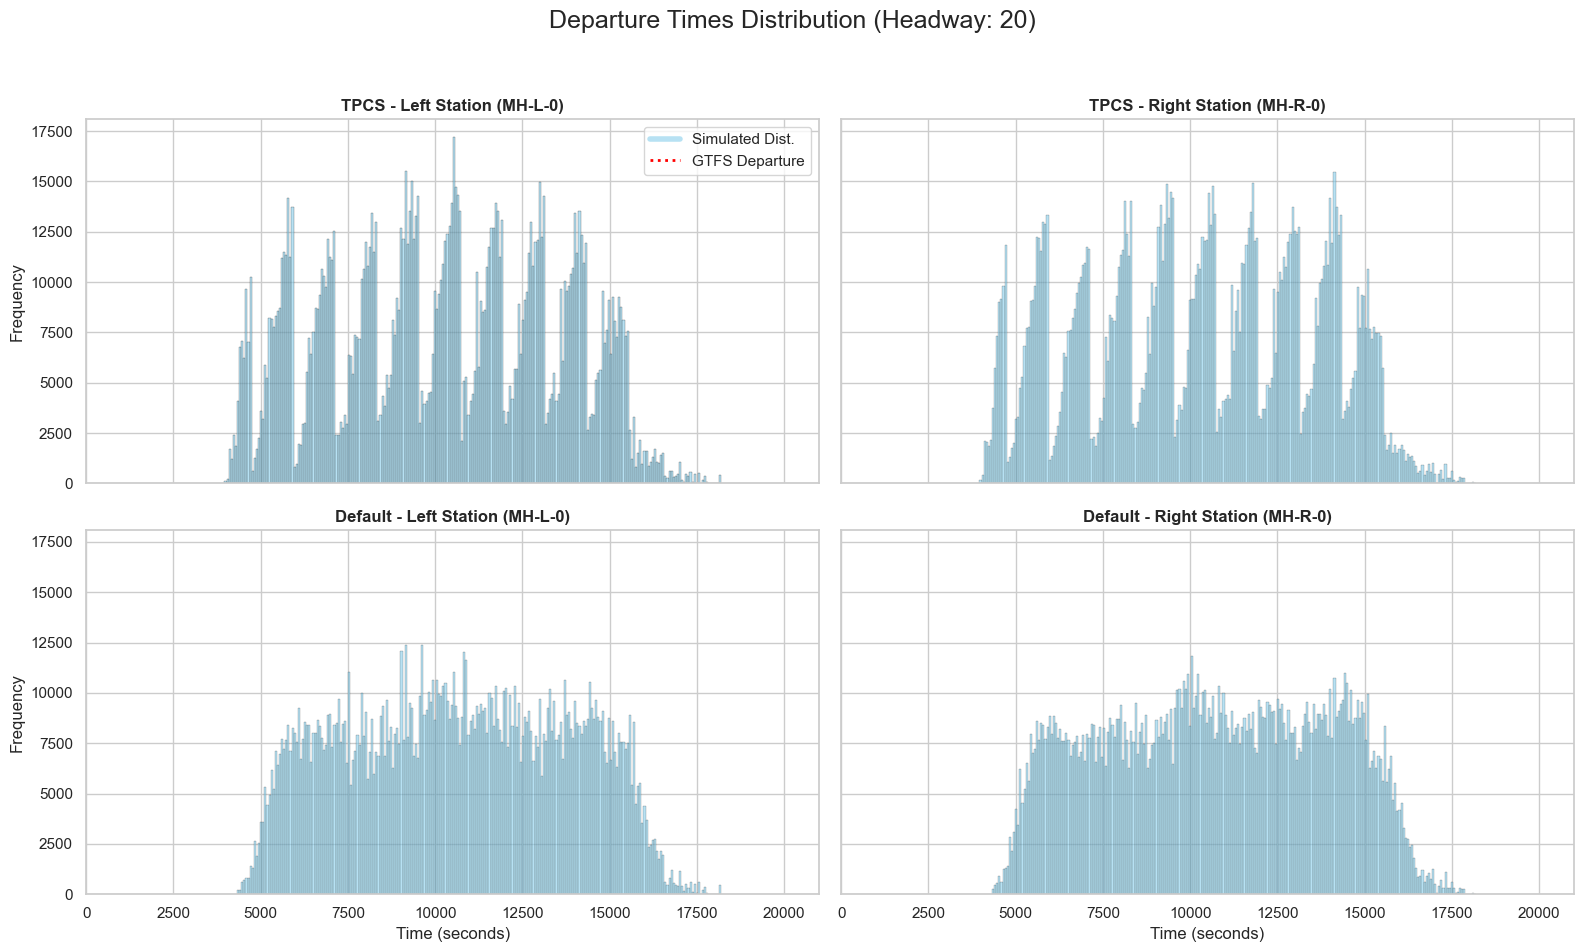

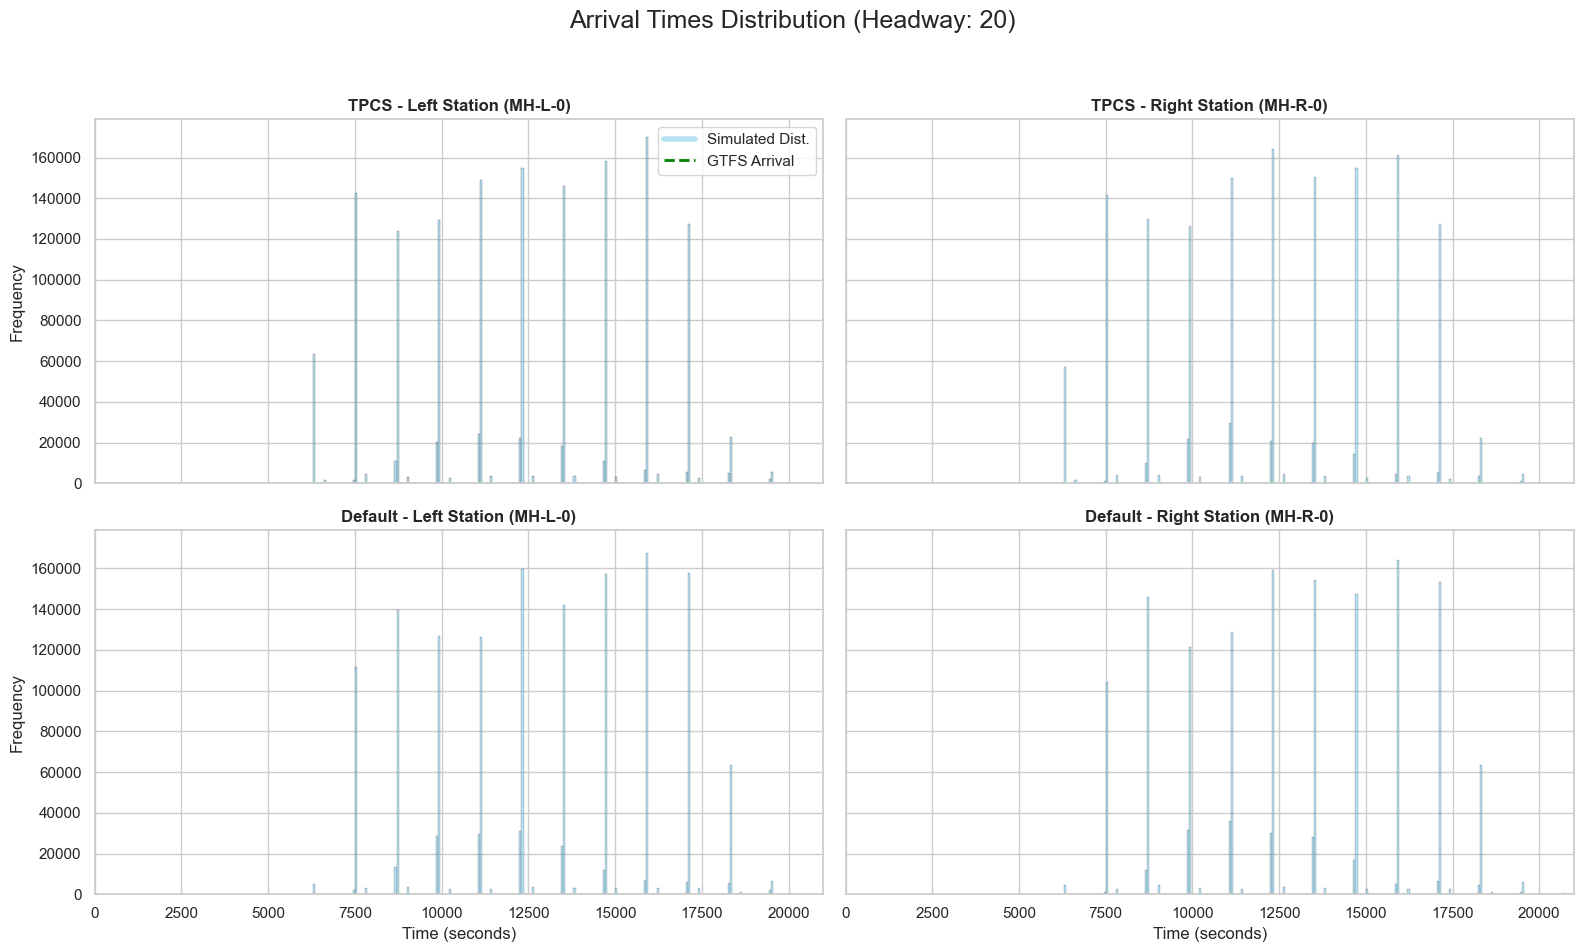

In [17]:
plot_arrival_distributions(arrival_dict=pt_station_arrival_times_dict, train_headway=20, gtfs_base_path='data/GTFS/train')

# Train 30 min

Reading GTFS file: data/GTFS/train\train_headway_30\matched\stop_times_fp.txt


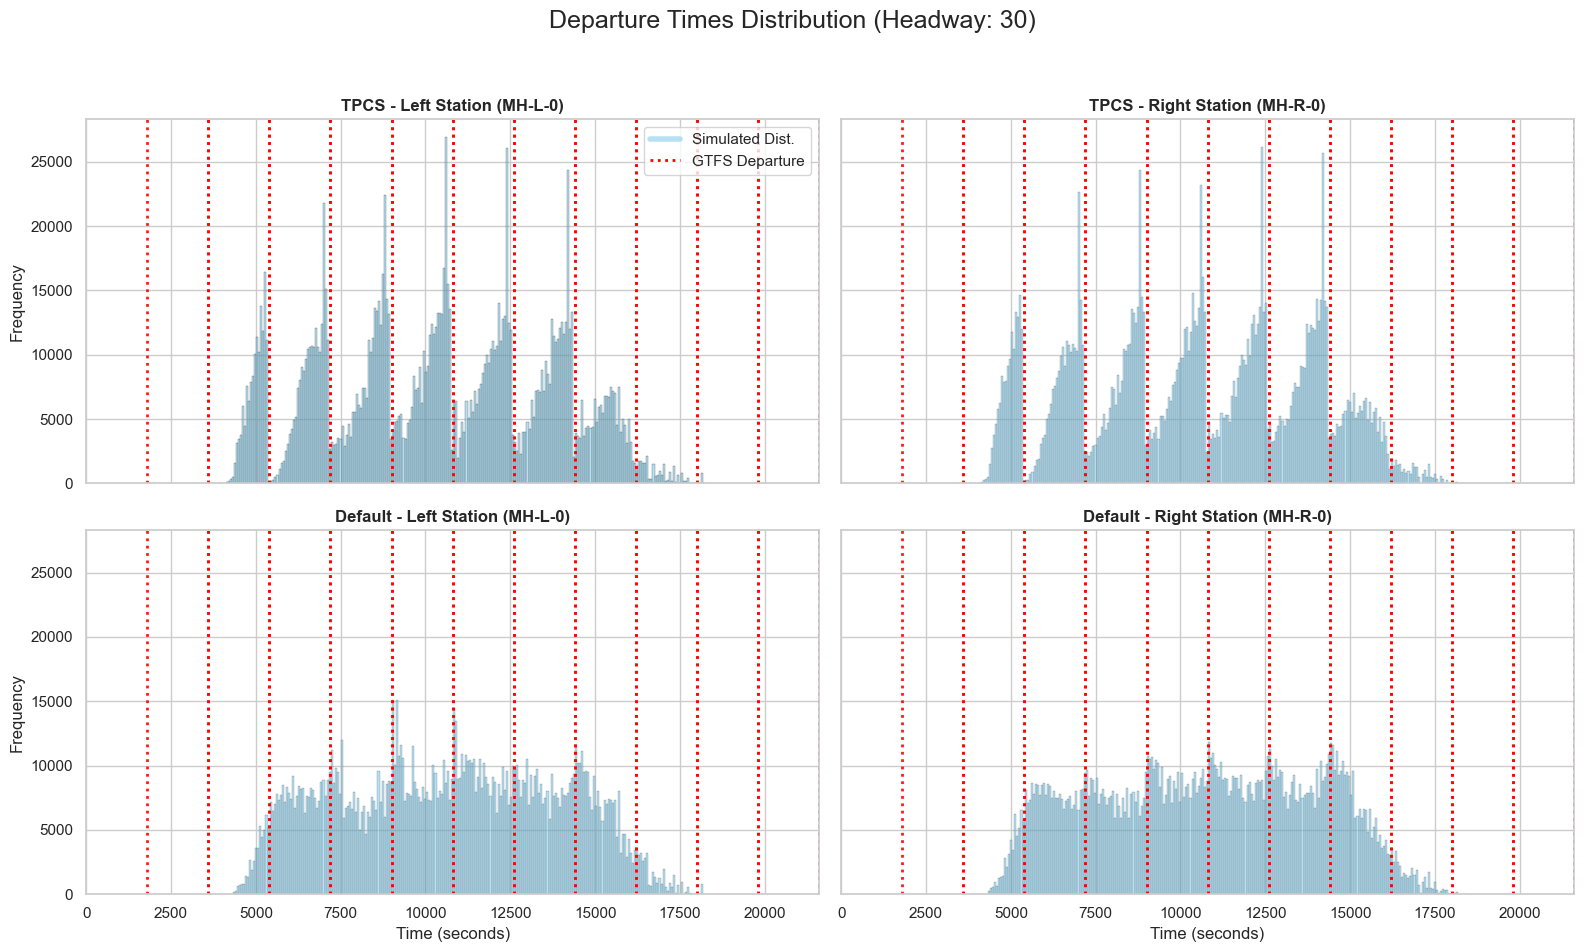

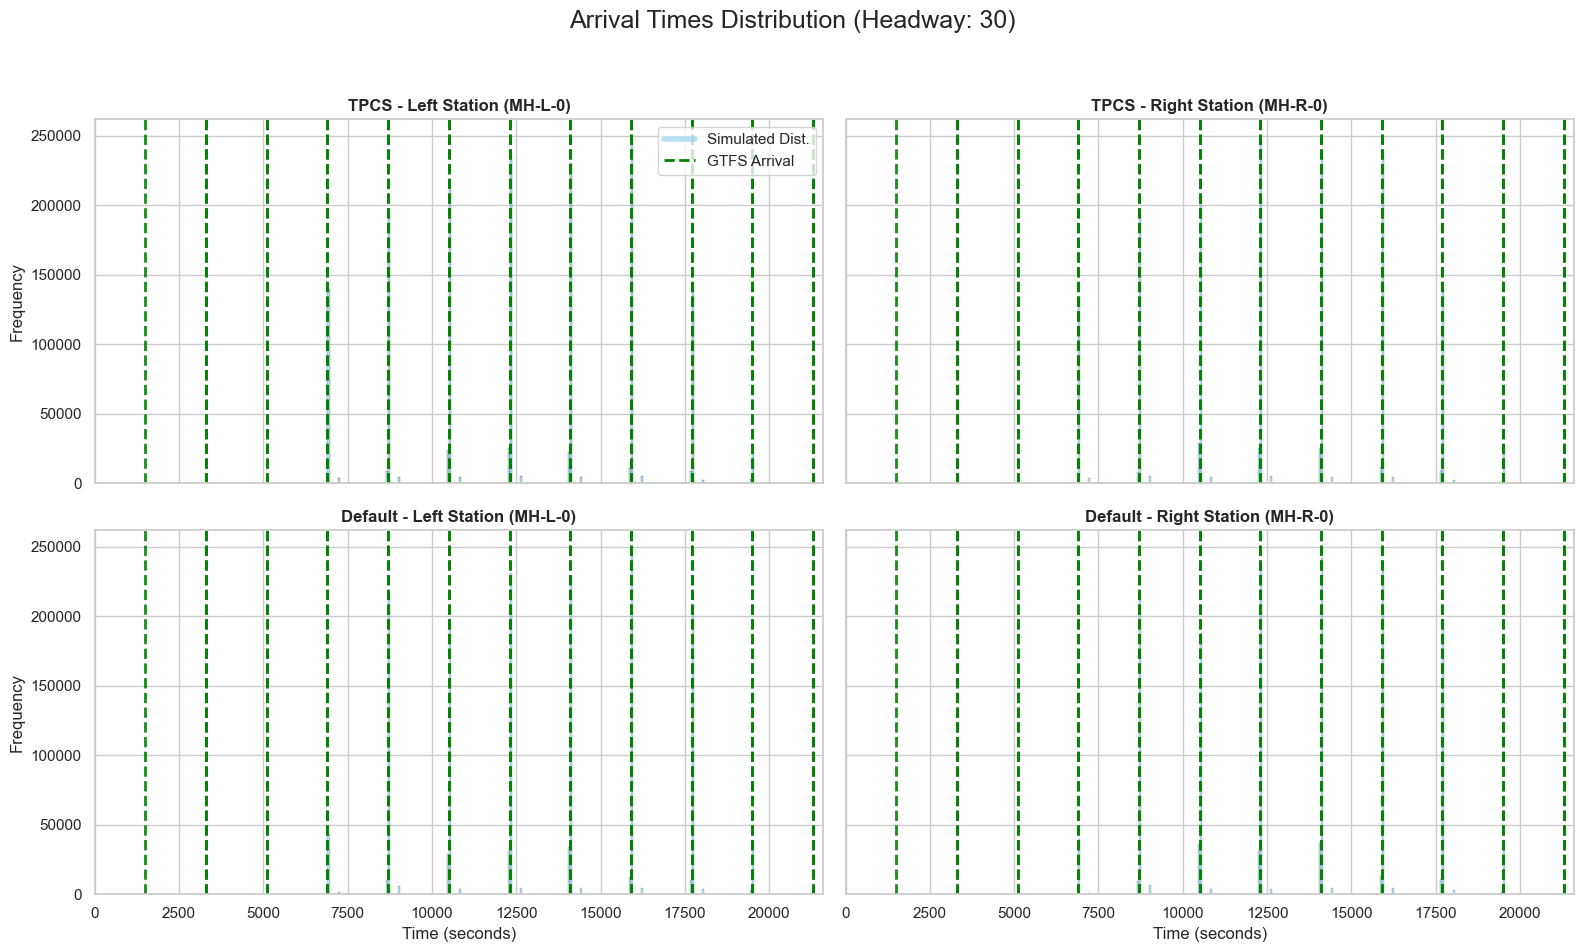

In [15]:
plot_arrival_distributions(arrival_dict=pt_station_arrival_times_dict, train_headway=30, gtfs_base_path='data/GTFS/train')